
# Elevator Vibration — Comprehensive Analysis (ISO 2631 & ISO 18738)

**Serial**: S0783L01A | **Sensor**: Door-mounted (single side)  
**Dates**: 2026-04-29 & 2026-03-30 | **Trips**: 10 sampled from S3

**Axes**: 
- **X**: Door open/close direction (door rattle, mechanical noise)
- **Y**: Lateral (side sway)
- **Z**: Vertical (cleanest axis, used for ride quality)


In [1]:

import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from IPython.display import display, Markdown

sys.path.insert(0, "../src")
from elevator_vibration import preprocessing as pp
from elevator_vibration import time_domain as td
from elevator_vibration import frequency as freq
from elevator_vibration import ride_quality as rq
from elevator_vibration import state_detection as sd
from elevator_vibration import diagnostics as diag
from elevator_vibration.data_loader import ElevatorDataLoader

plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (14, 6)})
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
np.set_printoptions(precision=3, suppress=True)


In [2]:

loader = ElevatorDataLoader()
serial = 'S0783L01A'

# Load top 5 trips from each date for comparison
april_refs = loader.list_all_trip_refs(serial, '2026-04-29')[:5]
march_refs = loader.list_all_trip_refs(serial, '2026-03-30')[:5]

all_trips = {}
for label, refs in [('April 29', april_refs), ('March 30', march_refs)]:
    for ref in refs:
        vib = loader.load_trip(ref)
        all_trips[ref.s3_key] = {
            'ax': vib.ax, 
            'ay': vib.ay, 
            'az': vib.az, 
            't': vib.time_seconds, 
            'date': label
        }

print(f"Loaded {len(all_trips)} trips from S3")
for k, v in sorted(all_trips.items()):
    print(f"  {v['date']}: {k.split('/')[-1]} | {len(v['ax'])} samples, {v['t'][-1]:.1f}s")


Loaded 10 trips from S3
  March 30: 2026-03-30T05:30:36:598915-2026-03-30T05:31:13:634498-f1-t10.zip | 4405 samples, 44.0s
  March 30: 2026-03-30T07:36:31:367591-2026-03-30T07:37:08:741615-f1-t10.zip | 4444 samples, 44.3s
  March 30: 2026-03-30T17:22:38:079049-2026-03-30T17:22:53:783937-f10-t12.zip | 2274 samples, 22.7s
  March 30: 2026-03-30T17:22:59:207852-2026-03-30T17:23:15:726047-f12-t14.zip | 2199 samples, 21.9s
  March 30: 2026-03-30T17:23:22:554489-2026-03-30T17:23:35:883600-f14-t13.zip | 2020 samples, 20.1s
  April 29: 2026-04-29T06:35:32:768618-2026-04-29T06:36:10:224528-f1-t10.zip | 4453 samples, 44.4s
  April 29: 2026-04-29T07:34:51:949976-2026-04-29T07:35:29:389598-f1-t10.zip | 4452 samples, 44.4s
  April 29: 2026-04-29T11:51:21:777140-2026-04-29T11:51:41:896830-f13-t10.zip | 2716 samples, 27.1s
  April 29: 2026-04-29T11:51:50:101514-2026-04-29T11:52:27:145365-f10-t1.zip | 4413 samples, 44.0s
  April 29: 2026-04-29T11:53:39:247173-2026-04-29T11:54:19:119171-f1-t11.zip | 46

In [3]:

state_results = {}
qc_results = []
metrics = []

for name, trip in sorted(all_trips.items()):
    ax, ay, az, t = trip['ax'], trip['ay'], trip['az'], trip['t']
    dt = np.median(np.diff(t))
    fs = 1.0 / dt
    
    az_dyn, gravity = pp.separate_gravity(az)
    noise = pp.estimate_noise_floor(ax, ay, az)
    door_mask = pp.door_operation_mask(ax)
    
    st = sd.analyze_trip_states(ax, ay, az, t, dt)
    state_results[name] = st
    
    # ISO Ride Quality (Z-only for door-mounted sensor)
    iso2631 = rq.iso2631_z_only(az, fs=fs)
    iso18738 = rq.iso18738_z_only(az_dyn, t, dt=dt)
    
    # Diagnostics
    report = diag.full_diagnostic_report(ax, ay, az, t, dt, state_analysis=st)
    
    metrics.append({
        'Key': name.split('/')[-1].replace('.zip', '')[:25],
        'Date': trip['date'],
        'Health': report['health_score'],
        'Rattle': st.door_rattle_index,
        'ISO_aw_z': iso2631['aw_z'] * 1000, # mg
        'A95_z': iso18738['global_composite_a95'], # m/s^2
        'Peak_Jerk': iso18738['global_jerk_peak'], # m/s^3
        'Unbalance': report['unbalance']['severity']
    })

df_metrics = pd.DataFrame(metrics)
display(df_metrics)


,Key,Date,Health,Rattle,ISO_aw_z,A95_z,Peak_Jerk,Unbalance
0,2026-03-30T05:30:36:59891,March 30,95,1.003410,4.686549,0.060580,1.130620,normal
1,2026-03-30T07:36:31:36759,March 30,95,1.000883,5.008031,0.061100,1.468080,normal
2,2026-03-30T17:22:38:07904,March 30,100,1.095390,3.173228,0.063081,0.868611,normal
3,2026-03-30T17:22:59:20785,March 30,90,1.095056,3.303904,0.063125,1.015332,normal
4,2026-03-30T17:23:22:55448,March 30,100,1.002448,3.631206,0.063087,1.547295,normal
5,2026-04-29T06:35:32:76861,April 29,95,1.072252,3.865596,0.060475,1.351603,normal
6,2026-04-29T07:34:51:94997,April 29,95,1.068578,5.513109,0.060823,0.917569,normal
7,2026-04-29T11:51:21:77714,April 29,100,0.936351,4.705774,0.062686,1.094909,normal
8,2026-04-29T11:51:50:10151,April 29,95,1.005773,5.948009,0.060908,1.449885,normal
9,2026-04-29T11:53:39:24717,April 29,95,1.000841,3.988478,0.060455,1.137917,normal


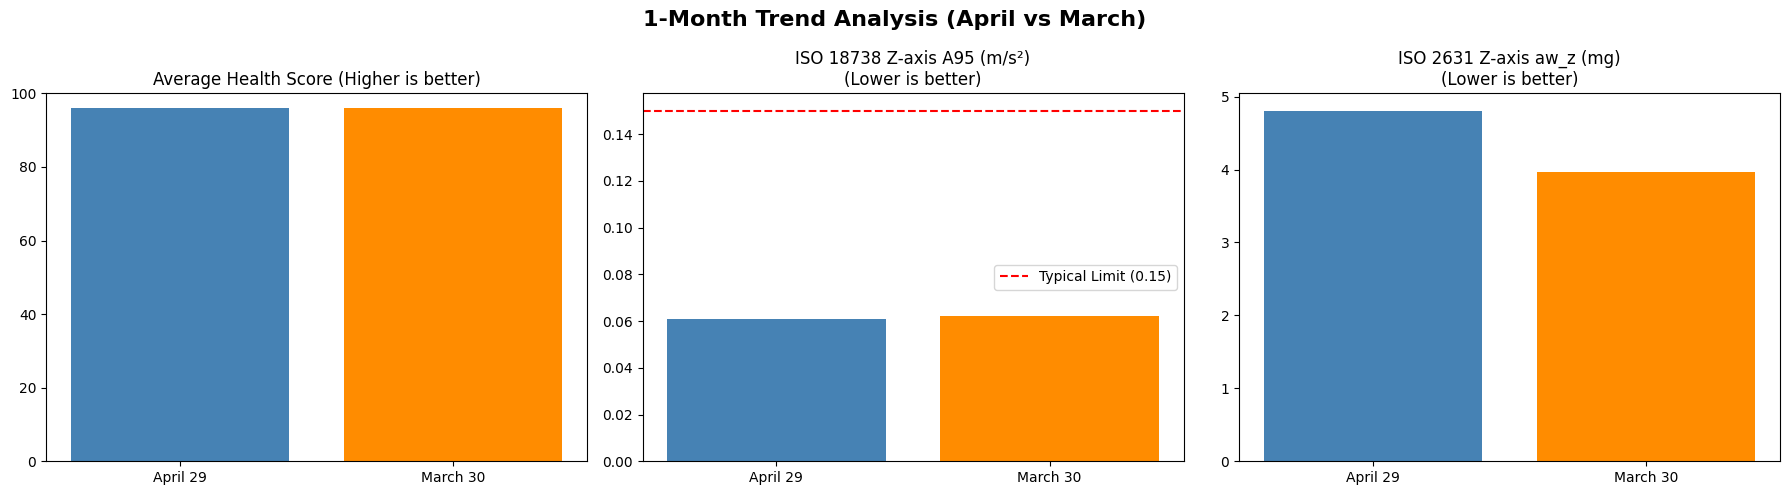

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Health Score
means = df_metrics.groupby('Date')['Health'].mean()
axes[0].bar(means.index, means.values, color=['steelblue', 'darkorange'])
axes[0].set_title("Average Health Score (Higher is better)")
axes[0].set_ylim(0, 100)

# ISO 18738 A95
means = df_metrics.groupby('Date')['A95_z'].mean()
axes[1].bar(means.index, means.values, color=['steelblue', 'darkorange'])
axes[1].set_title("ISO 18738 Z-axis A95 (m/s²)\n(Lower is better)")
axes[1].axhline(0.15, color='r', linestyle='--', label='Typical Limit (0.15)')
axes[1].legend()

# ISO 2631 aw_z
means = df_metrics.groupby('Date')['ISO_aw_z'].mean()
axes[2].bar(means.index, means.values, color=['steelblue', 'darkorange'])
axes[2].set_title("ISO 2631 Z-axis aw_z (mg)\n(Lower is better)")

fig.suptitle("1-Month Trend Analysis (April vs March)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
